# Baseline results


In [1]:
import os
import random
import warnings
from PIL import Image
from dotenv import load_dotenv
from rich import pretty, print, traceback, inspect

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
traceback.install(show_locals=True)
pretty.install()
load_dotenv();

In [2]:
positive_class = "Pneumonia"

## Load model


In [3]:

from model_chexagent.chexagent import CheXagent


chexagent = CheXagent()

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
2025-05-03 10:20:23.085441: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-03 10:20:23.088657: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-03 10:20:23.095668: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746292823.110127 2289137 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746292823.114398 2289137 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746292823.

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [4]:
chexagent.model


CheXagentForCausalLM(
  (model): CheXagentModel(
    (embed_tokens): Embedding(51200, 2560)
    (embed_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-31): 32 x PhiDecoderLayer(
        (self_attn): PhiAttention(
          (q_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (k_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (v_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (dense): Linear(in_features=2560, out_features=2560, bias=True)
          (rotary_emb): PhiRotaryEmbedding()
        )
        (mlp): PhiMLP(
          (activation_fn): NewGELUActivation()
          (fc1): Linear(in_features=2560, out_features=10240, bias=True)
          (fc2): Linear(in_features=10240, out_features=2560, bias=True)
        )
        (input_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (final_layernorm): Layer

## Load dataset


In [5]:
from datasets import load_dataset, Dataset

data_path = "/home/nicoleg/physionet.org/files/mimic-cxr-jpg/2.0.0"
ds: Dataset = load_dataset("nclgbd/mimic-cxr-embeds", split="test")

['No Finding']

FINAL REPORT
 CLINICAL HISTORY:  Esophageal adenocarcinoma status post stenting procedure. 
 Evaluate for stent position.
 
 A mesh stent is seen traversing from the left upper abdomen across the midline
 and anteriorly.  This is not in the esophagus.
 
 Multiple pulmonary lung metastases are again noted.
 
 IMPRESSION:  Stent in the abdomen, running transversely across the midline.

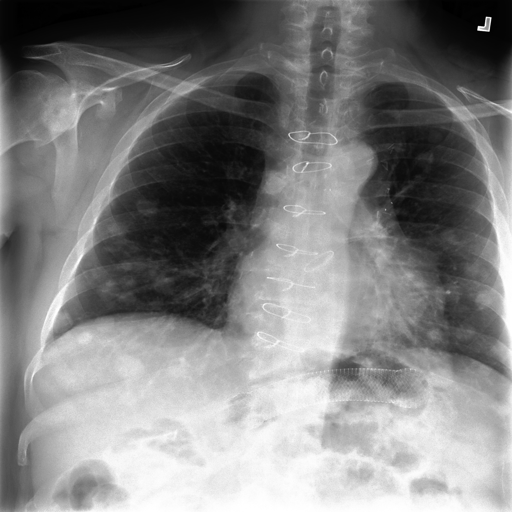

In [6]:
sample = random.choice(ds)
image_path = os.path.join(data_path, sample["image_files"])
print(sample["multiclass_labels"])
print(sample["reports"])
images = [Image.open(image_path).convert("RGB")]
images[0].resize((512, 512))

In [7]:
# Binary Disease Classification
path = image_path
response = chexagent.binary_disease_classification([path], positive_class)
print(f"Image: {path}")
print(f"Evaluating for: {positive_class}")
print(f"Result: {response}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Image: 
/home/nicoleg/physionet.org/files/mimic-cxr-jpg/2.0.0/files/p16/p16773796/s53145122/49ca0fba-77f367ba-c777cc0f-ca6a
a64d-327c39da.jpg

Evaluating for: Pneumonia

Result: No

# Get results


In [8]:
!nvidia-smi

Sat May  3 10:20:42 2025       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.256.02   Driver Version: 470.256.02   CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ...  Off  | 00000000:19:00.0 Off |                  N/A |
| 16%   37C    P2    44W / 250W |   3773MiB / 11019MiB |      2%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA GeForce ...  Off  | 00000000:1A:00.0 Off |                  N/A |
| 17%   

In [9]:
from tqdm import tqdm

rerun = False
if rerun:
    results = {}
    yes_no = {"yes": 1, "no": 0}
    for sample in tqdm(ds.shuffle(seed=42)):
        dicom_id = sample["dicom_id"]
        ytrue = True if positive_class in sample["multiclass_labels"] else False
        ytrue = int(ytrue)
        path = os.path.join(data_path, sample["image_files"])
        response = chexagent.binary_disease_classification([path], positive_class).lower()
        ypred = yes_no[response]
        results[dicom_id] = {
            "y_true": ytrue,
            "y_pred": ypred,
            "report": sample["reports"],
            "image_files": path,
        }

In [10]:
import pandas as pd

if "results.csv" in os.listdir("./") or not rerun:
    df = pd.read_csv("results.csv", index_col="dicom_id")
else:
    df = pd.DataFrame.from_dict(results, orient="index")
    df.index.name = "dicom_id"
    df.to_csv("results.csv")

df

,y_true,y_pred,report,image_files
dicom_id,,,,
19254d2e-12f84a8a-3d9be406-77b33fc9-ff7ed852,1,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
1d1b1649-61056b25-922ea810-d353c844-6a089756,1,1,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
4f32b256-67629057-efe5e52b-06323e27-46eeb15b,0,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
264b773c-cd573e36-8b42c4fd-971c4302-1946ed5a,0,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
dc1267a2-3ee022b5-d80f7ef1-f88a4e83-8d0de660,0,1,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
...,...,...,...,...
0d930f0a-46f813a9-db3b137b-05142eef-eca3c5a7,0,0,PROVISIONAL FINDINGS IMPRESSION (PFI): ___ __...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
973f7776-683260ca-ddf5aa13-cf5e3cb1-e2828914,0,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
c536f749-2326f755-6a65f28f-469affd2-26392ce9,0,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...


In [11]:
y_true = df["y_true"].values
y_pred = df["y_pred"].values
target_names = [f"No {positive_class}", positive_class]


def generate_classification_report(
    y_true, y_pred, target_names=[f"No Pneumonia", "Pneumonia"]
):
    """
    Generate a classification report and confusion matrix.

    Parameters:
    -----------
    y_true : array-like
        True labels
    y_pred : array-like
        Predicted labels
    target_names : list
        List of class names

    Returns:
    --------
    cr : dict
        Classification report as a dictionary
    """
    from sklearn.metrics import classification_report, confusion_matrix
    from tabulate import tabulate

    # Classification report
    cr_string = classification_report(y_true, y_pred, target_names=target_names)
    cr = classification_report(
        y_true, y_pred, target_names=target_names, output_dict=True
    )
    print("Classification Report:")
    print(cr_string)

    # Confusion matrix
    print("Confusion Matrix:")
    cfm = confusion_matrix(y_true, y_pred)
    print(
        tabulate(
            cfm, headers=target_names, showindex=target_names, tablefmt="rounded_grid"
        )
    )
    return cr


cr = generate_classification_report(
    y_true,
    y_pred,
    target_names=target_names,
)

Classification Report:

precision    recall  f1-score   support

No Pneumonia       0.93      0.89      0.91      2388
   Pneumonia       0.33      0.45      0.38       294

    accuracy                           0.84      2682
   macro avg       0.63      0.67      0.64      2682
weighted avg       0.86      0.84      0.85      2682

Confusion Matrix:

╭──────────────┬────────────────┬─────────────╮
│              │   No Pneumonia │   Pneumonia │
├──────────────┼────────────────┼─────────────┤
│ No Pneumonia │           2118 │         270 │
├──────────────┼────────────────┼─────────────┤
│ Pneumonia    │            163 │         131 │
╰──────────────┴────────────────┴─────────────╯

In [12]:
summary = pd.DataFrame(
    {
        "f1-score": round(cr["macro avg"]["f1-score"], 4),
        # "roc auc": round(roc_auc_score(y_true, y_pred), 4),
        "sensitivity": round(cr["Pneumonia"]["recall"], 4),
        "specificity": round(cr["No Pneumonia"]["recall"], 4),
        "recall": round(cr["macro avg"]["recall"], 4),
        "precision": round(cr["macro avg"]["precision"], 4),
        "accuracy": round(cr["accuracy"], 4),
    },
    index=["chexagent"],
)
summary

,f1-score,sensitivity,specificity,recall,precision,accuracy
chexagent,0.6421,0.4456,0.8869,0.6663,0.6276,0.8386


## Filter results

In [13]:
filtered_data = "/home/nicoleg/workspaces/dissertation/notebooks/results/mini-internvl2-1b-da-medical_response_df.csv"
llm_resp = pd.read_csv(filtered_data).set_index("dicom_id")
llm_resp = llm_resp[llm_resp["mimic_labels"] == llm_resp["llm_responses"]]
indices = list(set(llm_resp.index).intersection(set(df.index)))
fdf = df.loc[indices]
fdf

,y_true,y_pred,report,image_files
dicom_id,,,,
e8a8bd48-feafd477-16f9cfa0-575478d2-bc2c5cbb,0,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
bce5d9b0-6d67ccea-45044d9d-e4136b2d-643464ce,0,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
bfa3c5fe-e3616a0b-f2cede25-46b58e40-679b44d1,0,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
158479af-cf9c24d6-99ee742e-bbb91960-bfa7f46c,0,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
9c04078c-dee8c858-bc2a105e-d5fb538e-ac5a7c69,0,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
...,...,...,...,...
e3fc5bd6-0ebd345c-dd63d96c-6844627c-1b6cf82b,0,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
37d5e0a8-71e3174e-de2a7542-4cb0ba66-76531312,0,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
0b935875-ccc24ae1-ff220578-be4e3835-6acc2e7a,0,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...


In [14]:
y_true = fdf["y_true"].values
y_pred = fdf["y_pred"].values

cr = generate_classification_report(
    y_true,
    y_pred,
    target_names=target_names,
)

Classification Report:

precision    recall  f1-score   support

No Pneumonia       0.93      0.92      0.93      1731
   Pneumonia       0.47      0.52      0.49       234

    accuracy                           0.87      1965
   macro avg       0.70      0.72      0.71      1965
weighted avg       0.88      0.87      0.88      1965

Confusion Matrix:

╭──────────────┬────────────────┬─────────────╮
│              │   No Pneumonia │   Pneumonia │
├──────────────┼────────────────┼─────────────┤
│ No Pneumonia │           1593 │         138 │
├──────────────┼────────────────┼─────────────┤
│ Pneumonia    │            112 │         122 │
╰──────────────┴────────────────┴─────────────╯

In [15]:
summary = pd.DataFrame(
    {
        "f1-score": round(cr["macro avg"]["f1-score"], 4),
        # "roc auc": round(roc_auc_score(y_true, y_pred), 4),
        "sensitivity": round(cr["Pneumonia"]["recall"], 4),
        "specificity": round(cr["No Pneumonia"]["recall"], 4),
        "recall": round(cr["macro avg"]["recall"], 4),
        "precision": round(cr["macro avg"]["precision"], 4),
        "accuracy": round(cr["accuracy"], 4),
    },
    index=["filtered"],
)
summary

,f1-score,sensitivity,specificity,recall,precision,accuracy
filtered,0.7106,0.5214,0.9203,0.7208,0.7018,0.8728


# Error analysis

In [16]:
incorrects = fdf[fdf["y_true"] != fdf["y_pred"]]
incorrects

,y_true,y_pred,report,image_files
dicom_id,,,,
da5580a4-d85e8eac-795ffec6-41e6d24b-273b3747,1,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
76a5e5ee-2113aefe-e8d472a9-dff5f008-b1263281,1,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
8531a641-5f0bd3c1-b6e592c6-294f4e41-1dc643c3,0,1,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
b758e8f4-574ee6a8-32a4c691-81f94a5b-96a0773c,0,1,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
93894f42-2000f601-7b1944a8-7c4c0711-3d3a2a9b,0,1,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
...,...,...,...,...
ab062fe2-bf183eec-059ed8b1-b3b1917c-26fe6fdc,1,0,WET READ: ___ ___ ___ 12:00 PM\n Left lower ...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
34d6a1e6-c58e59d7-b03351e1-24e1191c-f74f6b2f,1,0,WET READ: ___ ___ ___ 10:04 PM\n Hyperinflat...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...
c4b67dd3-d40261f4-896ca5c9-acc7cde5-d93ec993,1,0,FINAL REPORT\...,/home/nicoleg/physionet.org/files/mimic-cxr-jp...


In [17]:
print(incorrects["y_pred"].value_counts())

y_pred
1    138
0    112
Name: count, dtype: int64

In [18]:
p_incorrects = incorrects[incorrects["y_pred"] == 1]
np_incorrects = incorrects[incorrects["y_pred"] == 0]

FINAL REPORT
 INDICATION:  ___ year old man with CHF with weight gain and dyspnea  //
 evaluate for volume overload/pulm edema/effusion
 
 TECHNIQUE:  Chest PA and lateral
 
 FINDINGS: 
 
 As compared to ___, interval worsening moderate pulmonary edema. 
 Right moderate pleural effusion has also slightly increased. Small left
 effusion persists.  Left lower lobe parenchymal opacity in the superior
 segment is now obscured by increasing pulmonary edema.  Moderate cardiomegaly.
 No pneumothorax.
 
 IMPRESSION: 
 
 Worsening moderate pulmonary edema as well as right moderate effusion.
 
  Left lower lobe parenchymal opacity in the superior segment is now obscured
 by increasing pulmonary edema.

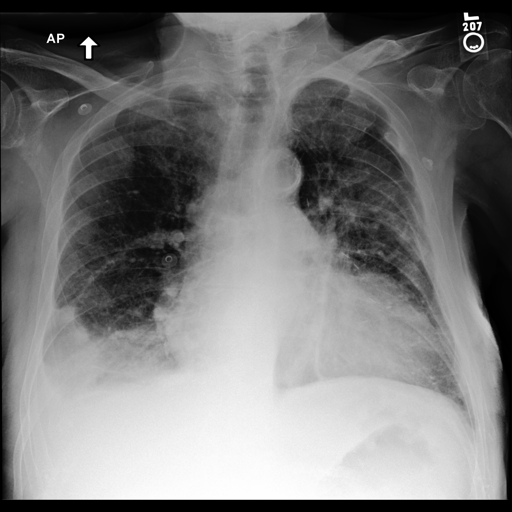

In [19]:
p_sample = incorrects.loc[random.choice(p_incorrects.index)]
report = p_sample["report"]
image_path = p_sample["image_files"]
print(report)
Image.open(image_path).convert("RGB").resize((512, 512))

FINAL REPORT
 HISTORY:  Temperature and confusion.
 
 FINDINGS:  In comparison with the study of ___, there is again substantial
 elevation of the right hemidiaphragmatic contour.  Opacification above this
 could reflect atelectasis, though in the appropriate clinical setting
 supervening pneumonia would have to be considered.
 
 Some prominence of the cardiac silhouette persists in a patient with intact
 midline sternal wires.  No evidence of vascular congestion and the left lung
 is essentially clear.

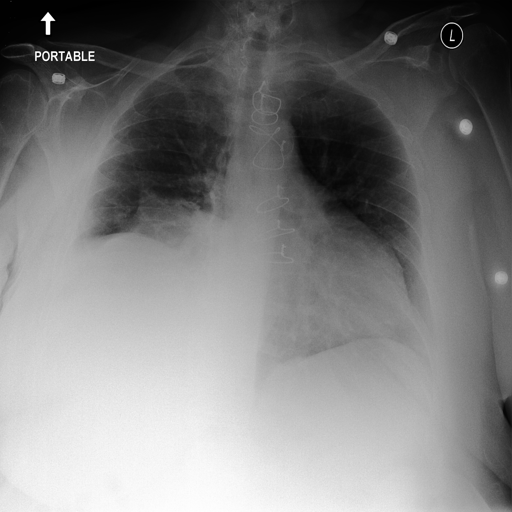

In [20]:
np_sample = incorrects.loc[random.choice(np_incorrects.index)]
report = np_sample["report"]
image_path = np_sample["image_files"]
print(report)
Image.open(image_path).convert("RGB").resize((512, 512))